In [512]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from scipy.stats import norm, binom

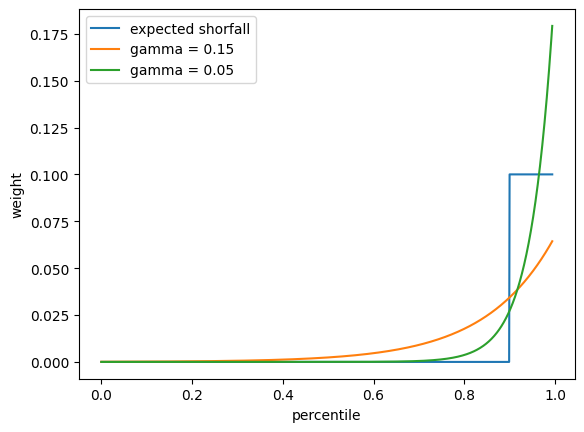

In [41]:
def spectral_risk(gamma, q, X = 0.9):
    return np.exp(-1*(1-q)/gamma)
def spectral_es(q, X = 0.9):
    if q < X:
        return 0
    return (1-X)
    
percentiles = np.arange(0,1000)*0.001
spectral_df = pd.DataFrame(
    {
        "expected shortfall" : [spectral_es(q) for q in percentiles],
        "gamma15" : [spectral_risk(0.15, q) for q in percentiles],
        "gamma05" : [spectral_risk(0.05, q) for q in percentiles]
    }
)
for col in spectral_df:
    spectral_df[col] = spectral_df[col] * 10/spectral_df[col].sum()

max_plot = 995
plt.plot(spectral_df.index[:max_plot]/1000, spectral_df["expected shortfall"][:max_plot], label = "expected shorfall")
plt.plot(spectral_df.index[:max_plot]/1000, spectral_df["gamma15"][:max_plot], label = "gamma = 0.15")
plt.plot(spectral_df.index[:max_plot]/1000, spectral_df["gamma05"][:max_plot], label= "gamma = 0.05")
plt.legend()
plt.xlabel("percentile")
plt.ylabel("weight")
plt.savefig('spectral_risk.png')


In [212]:
data = pd.read_csv("/home/shepj/data/european-stock-data.csv")

In [213]:
data.head()

,DATE-IBEX,VAL-IBEX,DATE-DAX,VAL-DAX,DATE-CAC,VAL-CAC,DATE-EUROSTOXX,VAL-EUROSTOXX
0,1/2/2006 17:36:00,10814.6,1/2/2006 20:00:00,5451.57,1/2/2006 17:30:00,4757.54,1/2/2006 18:00:00,3605.95
1,1/3/2006 17:36:00,10839.3,1/3/2006 20:00:00,5496.46,1/3/2006 17:30:00,4803.23,1/3/2006 18:00:00,3638.42
2,1/4/2006 17:36:00,10898.9,1/4/2006 20:00:00,5523.67,1/4/2006 17:30:00,4838.52,1/4/2006 18:00:00,3652.46
3,1/5/2006 17:36:00,10929.6,1/5/2006 20:00:00,5526.41,1/5/2006 17:30:00,4849.67,1/5/2006 18:00:00,3661.65
4,1/9/2006 17:36:00,10966.1,1/6/2006 20:00:00,5537.58,1/6/2006 17:30:00,4867.15,1/6/2006 18:00:00,3666.99


In [226]:
for date_col in [c for c in data.columns if "DATE" in c]:
    data[date_col] = pd.to_datetime(data[date_col]).dt.date

ftse = data[["DATE-IBEX", "VAL-IBEX"]]
ftse = ftse[~pd.isnull(ftse["DATE-IBEX"])]
cac = data[["DATE-CAC", "VAL-CAC"]]
cac = cac[~pd.isnull(cac["DATE-CAC"])]

dax = data[["DATE-DAX", "VAL-DAX"]]
dax = dax[~pd.isnull(dax["DATE-DAX"])]

es = data[["DATE-EUROSTOXX", "VAL-EUROSTOXX"]]
es = es[~pd.isnull(es["DATE-EUROSTOXX"])]

d1 = ftse.merge(cac, left_on="DATE-IBEX", right_on="DATE-CAC", how="outer")
d1["DATE"] = np.where(
    pd.isnull(d1["DATE-CAC"]),
    d1["DATE-IBEX"],
    d1["DATE-CAC"]
)
d1 = d1[["DATE", "VAL-IBEX", "VAL-CAC"]]

d1 = d1.merge(dax, left_on="DATE", right_on="DATE-DAX", how="outer")
d1["DATE"] = np.where(
    pd.isnull(d1["DATE"]),
    d1["DATE-DAX"],
    d1["DATE"]
)
d1 = d1[["DATE", "VAL-IBEX", "VAL-CAC", "VAL-DAX"]]

d1 = d1.merge(es, left_on="DATE", right_on="DATE-EUROSTOXX", how="outer")
d1["DATE"] = np.where(
    pd.isnull(d1["DATE"]),
    d1["DATE-EUROSTOXX"],
    d1["DATE"]
)
d1 = d1[["DATE", "VAL-IBEX", "VAL-CAC", "VAL-DAX", "VAL-EUROSTOXX"]]
d1.set_index("DATE", inplace=True)
d1.rename(columns = {c: re.sub("VAL-", "", c) for c in d1.columns}, inplace=True)
d1.ffill(inplace=True)
d1.bfill(inplace=True)

for col in d1.columns:
    vals = d1[col]
    diff = np.diff(d1[col], prepend=0)
    diff[0] = 0
    diff = diff/vals
    d1[f"{col}-SHOCK"] = diff 

d1


,IBEX,CAC,DAX,EUROSTOXX,IBEX-SHOCK,CAC-SHOCK,DAX-SHOCK,EUROSTOXX-SHOCK
DATE,,,,,,,,
2006-01-02,10814.6,4757.54,5451.57,3605.95,0.000000,0.000000,0.000000,0.000000
2006-01-03,10839.3,4803.23,5496.46,3638.42,0.002279,0.009512,0.008167,0.008924
2006-01-04,10898.9,4838.52,5523.67,3652.46,0.005468,0.007294,0.004926,0.003844
2006-01-05,10929.6,4849.67,5526.41,3661.65,0.002809,0.002299,0.000496,0.002510
2006-01-06,10929.6,4867.15,5537.58,3666.99,0.000000,0.003591,0.002017,0.001456
...,...,...,...,...,...,...,...,...
2023-12-21,10108.5,7574.71,16708.35,4524.86,-0.004917,-0.003994,-0.004884,-0.004685
2023-12-22,10143.1,7589.00,16735.32,4528.05,0.003411,0.001883,0.001612,0.000704
2023-12-27,10146.8,7603.27,16775.71,4542.33,0.000365,0.001877,0.002408,0.003144


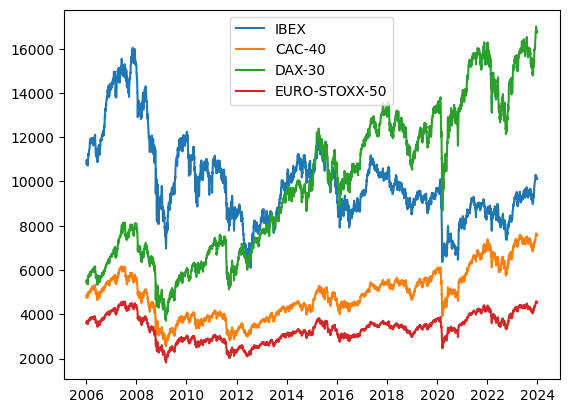

In [316]:
plt.plot(d1.index, d1["IBEX"], label="IBEX")
plt.plot(d1.index, d1["CAC"], label="CAC-40")
plt.plot(d1.index, d1["DAX"], label="DAX-30")
plt.plot(d1.index, d1["EUROSTOXX"],label="EURO-STOXX-50")
plt.legend()

plt.savefig("index-timeseries.png")

plt.show()

<Axes: ylabel='Frequency'>

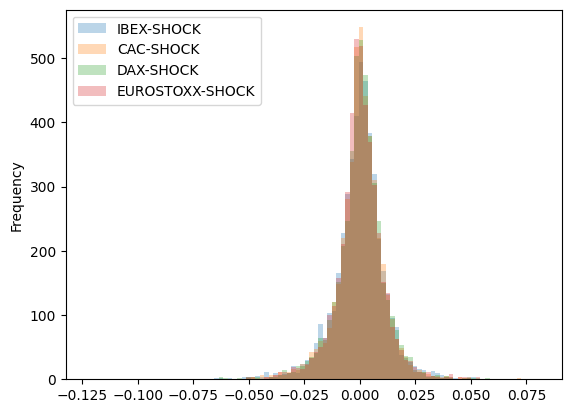

In [227]:
d1[[c for c in d1.columns if "SHOCK" in c]].plot.hist(bins=100, alpha=0.3)

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

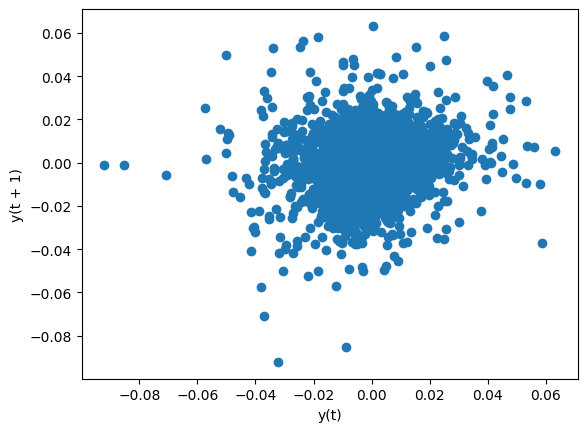

In [225]:
pd.plotting.lag_plot(d1["EUROSTOXX-DIFF"], lag=1)


In [228]:
obs_auto_corr = {}
for col in [col for col in d1.columns if "SHOCK" in col]:
    values = d1[col]
    d2 = pd.concat([values.shift(3), values.shift(2),
                       values.shift(1), values], axis=1)
    d2.columns = ['t', 't+1', 't+2', 't+3']
    result = d2.corr()
    obs_auto_corr[col] = result
    print(result)
    print("======")

            t       t+1       t+2       t+3
t    1.000000  0.097561  0.015885 -0.034606
t+1  0.097561  1.000000  0.097560  0.015886
t+2  0.015885  0.097560  1.000000  0.097559
t+3 -0.034606  0.015886  0.097559  1.000000
            t       t+1       t+2       t+3
t    1.000000  0.069625 -0.002956 -0.033219
t+1  0.069625  1.000000  0.069621 -0.002966
t+2 -0.002956  0.069621  1.000000  0.069627
t+3 -0.033219 -0.002966  0.069627  1.000000
            t       t+1       t+2       t+3
t    1.000000  0.078162  0.012230 -0.007628
t+1  0.078162  1.000000  0.078163  0.012224
t+2  0.012230  0.078163  1.000000  0.078162
t+3 -0.007628  0.012224  0.078162  1.000000
            t       t+1       t+2       t+3
t    1.000000  0.117102 -0.008401 -0.021770
t+1  0.117102  1.000000  0.117102 -0.008409
t+2 -0.008401  0.117102  1.000000  0.117101
t+3 -0.021770 -0.008409  0.117101  1.000000


In [229]:
print(df_to_latex(obs_auto_corr["EUROSTOXX-SHOCK"]))

\begin{tabular}{ l cccc}
\hline 
& t & t+1 & t+2 & t+3\\ 
\hline 
t & 1.00 & 0.12 & -0.01 & -0.02\\ 
t+1 & 0.12 & 1.00 & 0.12 & -0.01\\ 
t+2 & -0.01 & 0.12 & 1.00 & 0.12\\ 
t+3 & -0.02 & -0.01 & 0.12 & 1.00\\ 
\hline 
\end{tabular}


In [76]:
def t_day_var(sigma=1, rho=0, t=1):
    sum = t
    for j in range(1, t):
        sum += 2 * (t-j)*np.power(rho, j)
    return sigma*np.sqrt(sum)

effect_of_auto_correlation = [
    [t_day_var(rho=rho, t=t) for t in [1, 2, 5, 10, 50, 250]]
    for rho in [0,0.05, 0.1, 0.2]
]
x = effect_of_auto_correlation

In [192]:

tab = pd.DataFrame(x, columns=["T=1", "T=2", "T=5", "T=10", "T=50", "T=250"], 
             index = [f"$\\rho={y}$" for y in [0, 0.05, 0.1, 0.2]])
tab

,T=1,T=2,T=5,T=10,T=50,T=250
$\rho=0$,1.0,1.414214,2.236068,3.162278,7.071068,15.811388
$\rho=0.05$,1.0,1.449138,2.327125,3.307843,7.426463,16.619416
$\rho=0.1$,1.0,1.483240,2.421611,3.460536,7.801551,17.473083
$\rho=0.2$,1.0,1.549193,2.622060,3.791438,8.624094,19.348773


In [199]:
def df_to_latex(df):
    hline = "\\hline \n"
    str = "\\begin{tabular}{ l " +  "c" *len(df.columns) + "}\n"
    str += hline
    str += "& " + " & ".join(x for x in df.columns) + "\\\\ \n"
    str += hline
    for index, row in df.iterrows():
        str += f"{index}" +  " & " + " & ".join(f"{x:.02f}" for x in row.values) + "\\\\ \n"
    str +=  hline
    str += "\\end{tabular}"
    return str
print(df_to_latex(tab)) 


\begin{tabular}{ l cccccc}
\hline 
& T=1 & T=2 & T=5 & T=10 & T=50 & T=250\\ 
\hline 
$\rho=0$ & 1.00 & 1.41 & 2.24 & 3.16 & 7.07 & 15.81\\ 
$\rho=0.05$ & 1.00 & 1.45 & 2.33 & 3.31 & 7.43 & 16.62\\ 
$\rho=0.1$ & 1.00 & 1.48 & 2.42 & 3.46 & 7.80 & 17.47\\ 
$\rho=0.2$ & 1.00 & 1.55 & 2.62 & 3.79 & 8.62 & 19.35\\ 
\hline 
\end{tabular}


In [211]:
def ES_sigma_multiplier(beta):
    Y = norm.ppf(beta)
    return np.exp(-Y*Y/2)/(np.sqrt(2*np.pi)*(1 - beta))
ES_sigma_multiplier(0.975)

2.3378027922014133

(array([  1.,   2.,   4.,   2.,  12.,  42., 147., 220.,  52.,  17.,   5.,
          5.,   1.,   1.,   0.,   1.,   1.,   0.,   0.,   1.]),
 array([-649.08095557, -559.03477531, -468.98859505, -378.94241478,
        -288.89623452, -198.85005426, -108.803874  ,  -18.75769373,
          71.28848653,  161.33466679,  251.38084705,  341.42702732,
         431.47320758,  521.51938784,  611.5655681 ,  701.61174837,
         791.65792863,  881.70410889,  971.75028915, 1061.79646941,
        1151.84264968]),
 <BarContainer object of 20 artists>)

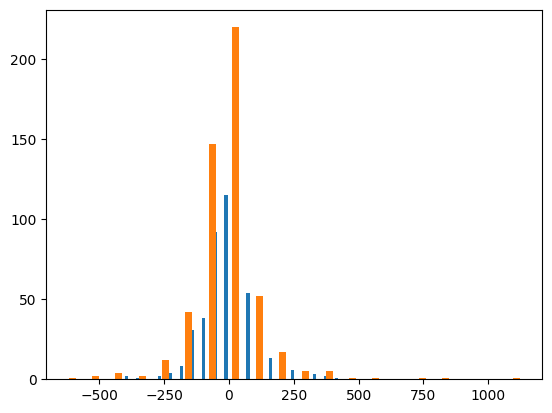

In [267]:
portfolio = {
    'CAC' : 3000,
    'DAX' : 4000,
    'IBEX' : 2000,
    'EUROSTOXX': 1000
}
def compute_portfolio_loss_scenarios(portfolio, shocks):
    loss_scenarios = shocks.copy()
    for k, v in portfolio.items():
        col = f"{k}-SHOCK"
        loss_scenarios[f"{k}-loss"] = -1*d1[col] * v
    loss_scenarios["portfolio-loss"] = loss_scenarios[[col for col in loss_scenarios.columns if "loss" in col]].sum(axis=1)
    return loss_scenarios
losses = compute_portfolio_loss_scenarios(portfolio, d1)
losses[losses.index >pd.to_datetime("2022-12-31").date()].sort_values("portfolio-loss")



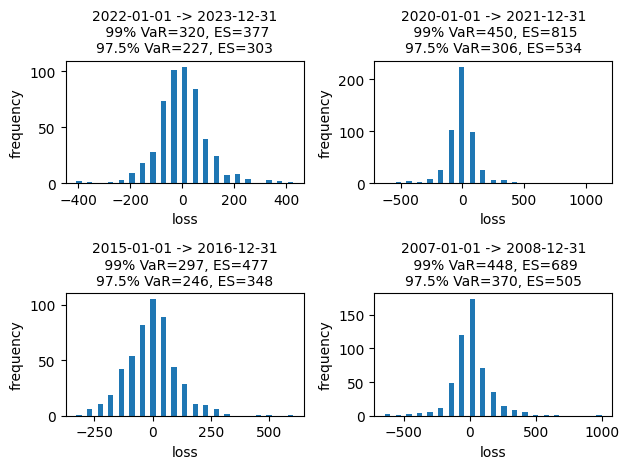

In [317]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(nrows=2, ncols=2)


all_tail_losses = {}
def make_ax(ax, start_date, end_date):
    vals = losses.loc[
        (losses.index >=pd.to_datetime(start_date).date()) 
        & (losses.index <pd.to_datetime(end_date).date()), 
        "portfolio-loss"
    ].values
    tail_losses = sorted(vals)[-int(len(vals)/100):]
    all_tail_losses[start_date] = tail_losses
    var_99 = tail_losses[0]
    es_99 = sum(tail_losses[1:])/(len(tail_losses)-1)
    tail_losses = sorted(vals)[-int(2.5*len(vals)/100):]
    all_tail_losses[start_date] = tail_losses
    var_975 = tail_losses[0]
    es_975 = sum(tail_losses[1:])/(len(tail_losses)-1)
    ax.hist(vals, 21, histtype='bar', rwidth = 0.5)
    ax.set_xlabel("loss")
    ax.set_ylabel("frequency")
    ax.set_title(
        f"{start_date} -> {end_date}\n 99% VaR={var_99:.0f}, ES={es_99:.0f}\n97.5% VaR={var_975:.0f}, ES={es_975:.0f}",
        fontsize=10
    )

make_ax(ax0, "2022-01-01", "2023-12-31")
make_ax(ax1, "2020-01-01", "2021-12-31")
make_ax(ax2, "2015-01-01", "2016-12-31")
make_ax(ax3, "2007-01-01", "2008-12-31")

fig.tight_layout()
fig.title = "distribution of losses"
plt.savefig("historical-var.png")
plt.show()



In [295]:
print(df_to_latex(pd.DataFrame(all_tail_losses)))

\begin{tabular}{ l cccc}
\hline 
& 2022-01-01 & 2020-01-01 & 2015-01-01 & 2007-01-01\\ 
\hline 
0 & 226.69 & 305.96 & 246.47 & 369.99\\ 
1 & 229.28 & 309.30 & 254.17 & 372.76\\ 
2 & 235.26 & 344.38 & 257.59 & 380.05\\ 
3 & 237.44 & 351.35 & 260.55 & 382.57\\ 
4 & 239.70 & 369.55 & 268.87 & 392.87\\ 
5 & 239.89 & 393.51 & 286.93 & 400.31\\ 
6 & 316.83 & 397.21 & 291.90 & 421.37\\ 
7 & 320.18 & 450.41 & 296.98 & 448.43\\ 
8 & 341.13 & 596.02 & 335.56 & 489.14\\ 
9 & 362.01 & 712.32 & 452.86 & 592.39\\ 
10 & 370.56 & 800.91 & 508.75 & 654.86\\ 
11 & 436.24 & 1151.84 & 612.80 & 1017.71\\ 
\hline 
\end{tabular}


In [281]:
len(vals)

1278

In [302]:
vals = d1[[col for col in d1.columns if 'SHOCK' in col]].values

In [308]:
np.cov(vals.T)

array([[0.000151  , 0.00012221, 0.00011461, 0.00011744],
       [0.00012221, 0.0001347 , 0.00012349, 0.00012071],
       [0.00011461, 0.00012349, 0.00013568, 0.00011835],
       [0.00011744, 0.00012071, 0.00011835, 0.00012369]])

In [315]:
index_names = ["IBEX", "CAC", "DAX", "EUROSTOXX"]
print(pd.DataFrame(np.cov(vals.T), columns = index_names, index= index_names ).to_latex())

\begin{tabular}{lrrrr}
\toprule
 & IBEX & CAC & DAX & EUROSTOXX \\
\midrule
IBEX & 0.000151 & 0.000122 & 0.000115 & 0.000117 \\
CAC & 0.000122 & 0.000135 & 0.000123 & 0.000121 \\
DAX & 0.000115 & 0.000123 & 0.000136 & 0.000118 \\
EUROSTOXX & 0.000117 & 0.000121 & 0.000118 & 0.000124 \\
\bottomrule
\end{tabular}



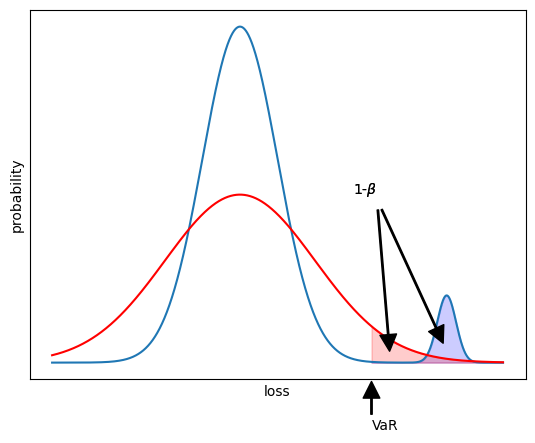

In [436]:
x = np.linspace(-100, 140, 10000)
y = norm.pdf(x, 0, 20) + 0.05*norm.pdf(x, 110, 5)
plt.plot(x, y)
plt.fill_between(x, y, -0.00,where= x>70,color='blue', alpha=.2)
y1 = norm.pdf(x, 0, 40)
plt.plot(x, y1,color='red')
plt.fill_between(x, y1, -0.00,where= x>70,color='red', alpha=.2)
plt.xlabel("loss")
plt.ylabel("probability")
plt.xticks([])
plt.yticks([])
plt.annotate(r'1-$\beta$', xy=(110, 0.0007), xytext=(60,.01),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1),
            )
plt.annotate(r'1-$\beta$', xy=(80, 0.0002), xytext=(60,.01),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1),
            )
plt.annotate('VaR', xy=(70, -0.001), xytext=(70,-.004),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1),
            )
plt.savefig("var-tail.png")

In [417]:
def strangle_payoff(x, strike1=0.7, strike2=0.7, cost=0):
    return (max(x - strike1, -cost) - max(x - strike2, -cost) )

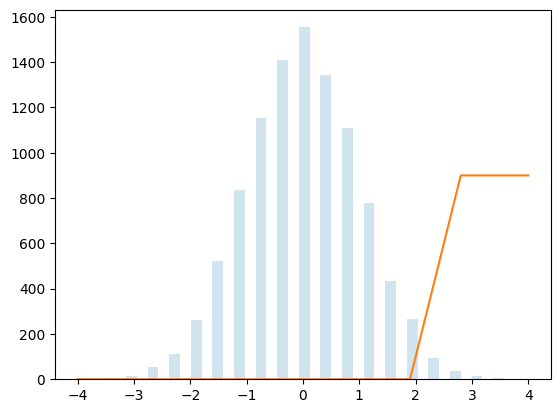

In [437]:
vals = norm.rvs(0, 1, 10000)
xx = np.linspace(-4, 4, 1000)
loss = [1000*strangle_payoff(x, 1.4, 2.3, -0.5) for x in xx]
plt.hist(vals, bins=20, rwidth = 0.5, alpha=0.2)
plt.plot(xx, loss)
loss2 = [1000*strangle_payoff(x, 1.4, 2.3, -0.5) for x in vals]
plt.show()

In [474]:
[col for col in d1.columns if "SHOCK" in col]

['IBEX-SHOCK', 'CAC-SHOCK', 'DAX-SHOCK', 'EUROSTOXX-SHOCK']

In [508]:
#cov = d1.loc[[col for col in d1.columns if "SHOCK" in col]].cov().values

start_date = "2022-01-01"
end_date = "2023-12-31"
cov = d1.loc[
        (d1.index >=pd.to_datetime(start_date).date()) 
        & (d1.index <pd.to_datetime(end_date).date()), 
        [ "CAC-SHOCK", "DAX-SHOCK", "IBEX-SHOCK", "EUROSTOXX-SHOCK", ]
].cov()
np.dot( np.dot(port_factors, cov.values), port_factors.T)

9329.283012734933

In [511]:
print(cov.to_latex())

\begin{tabular}{lrrrr}
\toprule
 & CAC-SHOCK & DAX-SHOCK & IBEX-SHOCK & EUROSTOXX-SHOCK \\
\midrule
CAC-SHOCK & 0.000102 & 0.000097 & 0.000080 & 0.000094 \\
DAX-SHOCK & 0.000097 & 0.000108 & 0.000082 & 0.000096 \\
IBEX-SHOCK & 0.000080 & 0.000082 & 0.000089 & 0.000076 \\
EUROSTOXX-SHOCK & 0.000094 & 0.000096 & 0.000076 & 0.000096 \\
\bottomrule
\end{tabular}



In [509]:
port_factors = np.array(list(portfolio.values()))
std_dev = np.sqrt( np.dot( np.dot(port_factors, cov), port_factors.T) )
print( f"VaR = {std_dev * norm.ppf(0.99)}")
print( f"ES = {ES_sigma_multiplier(0.99) * std_dev}")

VaR = 224.69778544157936
ES = 257.4282804913787


In [501]:
port_factors

array([3000, 4000, 2000, 1000])

In [464]:
print( df_to_latex(pd.DataFrame(portfolio, index = [1])) )

\begin{tabular}{ l cccc}
\hline 
& CAC & DAX & IBEX & EUROSTOXX\\ 
\hline 
1 & 3000.00 & 4000.00 & 2000.00 & 1000.00\\ 
\hline 
\end{tabular}


In [470]:
print(df_to_latex(d1[list(portfolio.keys())].head()))

\begin{tabular}{ l cccc}
\hline 
& CAC & DAX & IBEX & EUROSTOXX\\ 
\hline 
2006-01-02 & 4757.54 & 5451.57 & 10814.60 & 3605.95\\ 
2006-01-03 & 4803.23 & 5496.46 & 10839.30 & 3638.42\\ 
2006-01-04 & 4838.52 & 5523.67 & 10898.90 & 3652.46\\ 
2006-01-05 & 4849.67 & 5526.41 & 10929.60 & 3661.65\\ 
2006-01-06 & 4867.15 & 5537.58 & 10929.60 & 3666.99\\ 
\hline 
\end{tabular}


In [520]:
binom.sf(11,500, 0.01)

0.0052080442541713266